In [1]:
import pandas as pd

df = pd.read_csv('data/raw/wc2022_events.csv')
print(df.shape)

C:\Users\Susan\AppData\Local\Temp\ipykernel_4444\4148347009.py:3: DtypeWarning: Columns (0: 50_50, 1: block_deflection, 2: clearance_other, 3: dribble_no_touch, 4: injury_stoppage_in_chain, 5: miscontrol_aerial_won, 6: pass_deflected, 7: pass_goal_assist, 8: pass_inswinging, 9: pass_miscommunication, 10: shot_one_on_one, 11: shot_open_goal, 12: block_offensive, 13: foul_committed_offensive, 14: foul_committed_penalty, 15: foul_committed_type, 16: foul_won_penalty, 17: goalkeeper_shot_saved_to_post, 18: pass_cut_back, 19: shot_deflected, 20: shot_saved_to_post, 21: ball_recovery_offensive, 22: pass_no_touch, 23: pass_straight, 24: shot_redirect, 25: goalkeeper_punched_out, 26: bad_behaviour_card, 27: block_save_block, 28: goalkeeper_shot_saved_off_target, 29: shot_saved_off_target, 30: goalkeeper_success_in_play, 31: shot_follows_dribble, 32: half_start_late_video_start, 33: goalkeeper_lost_in_play) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read

(234637, 114)


In [2]:
df = pd.read_csv('data/raw/wc2022_events.csv', low_memory=False)

In [3]:
print(df['type'].value_counts())

type
Pass                 68515
Ball Receipt*        63699
Carry                53764
Pressure             16554
Ball Recovery         5821
Duel                  4389
Clearance             2684
Block                 2386
Dribble               1793
Goal Keeper           1790
Foul Committed        1775
Miscontrol            1755
Foul Won              1693
Shot                  1494
Dispossessed          1431
Interception          1371
Dribbled Past         1036
Substitution           587
Injury Stoppage        403
Half Start             286
Half End               286
Tactical Shift         243
50/50                  236
Referee Ball-Drop      162
Starting XI            128
Shield                 104
Player Off              74
Player On               74
Bad Behaviour           44
Error                   28
Offside                 26
Own Goal For             3
Own Goal Against         3
Name: count, dtype: int64


In [4]:
dribbles = df[df['type'] == 'Dribble'].copy()
print(dribbles.shape)
print(dribbles['dribble_nutmeg'].value_counts(dropna=False))

(1793, 114)
dribble_nutmeg
NaN     1648
True     145
Name: count, dtype: int64


In [5]:
dribbles['dribble_nutmeg'] = dribbles['dribble_nutmeg'].fillna(False)
print(dribbles['dribble_nutmeg'].value_counts())

dribble_nutmeg
False    1648
True      145
Name: count, dtype: int64


In [6]:
print(f"Nutmeg rate: {145/1793*100:.1f}%")

Nutmeg rate: 8.1%


In [7]:
nutmegs = dribbles[dribbles['dribble_nutmeg'] == True]
print(nutmegs['player'].value_counts().head(10))

player
Kylian Mbappé Lottin               5
Antony Matheus dos Santos          4
Daniel Olmo Carvajal               3
Cody Mathès Gakpo                  3
Ángel Fabián Di María Hernández    3
Ivan Perišić                       3
Neymar da Silva Santos Junior      3
Rodrygo Silva de Goes              3
Tajon Buchanan                     2
Hakim Ziyech                       2
Name: count, dtype: int64


In [8]:
print(nutmegs['team'].value_counts().head(10))

team
Brazil       16
Portugal     11
Argentina    10
Croatia       8
Canada        7
Spain         7
Australia     7
England       6
France        6
Germany       6
Name: count, dtype: int64


In [9]:
import ast

dribbles['x'] = dribbles['location'].apply(lambda loc: ast.literal_eval(loc)[0])
dribbles['y'] = dribbles['location'].apply(lambda loc: ast.literal_eval(loc)[1])

print(dribbles[dribbles['dribble_nutmeg']==True][['x','y']].describe())

                x           y
count  145.000000  145.000000
mean    77.981379   39.353793
std     27.593563   27.896615
min      9.000000    0.800000
25%     57.000000   11.700000
50%     82.700000   32.000000
75%    102.600000   68.400000
max    117.900000   79.000000


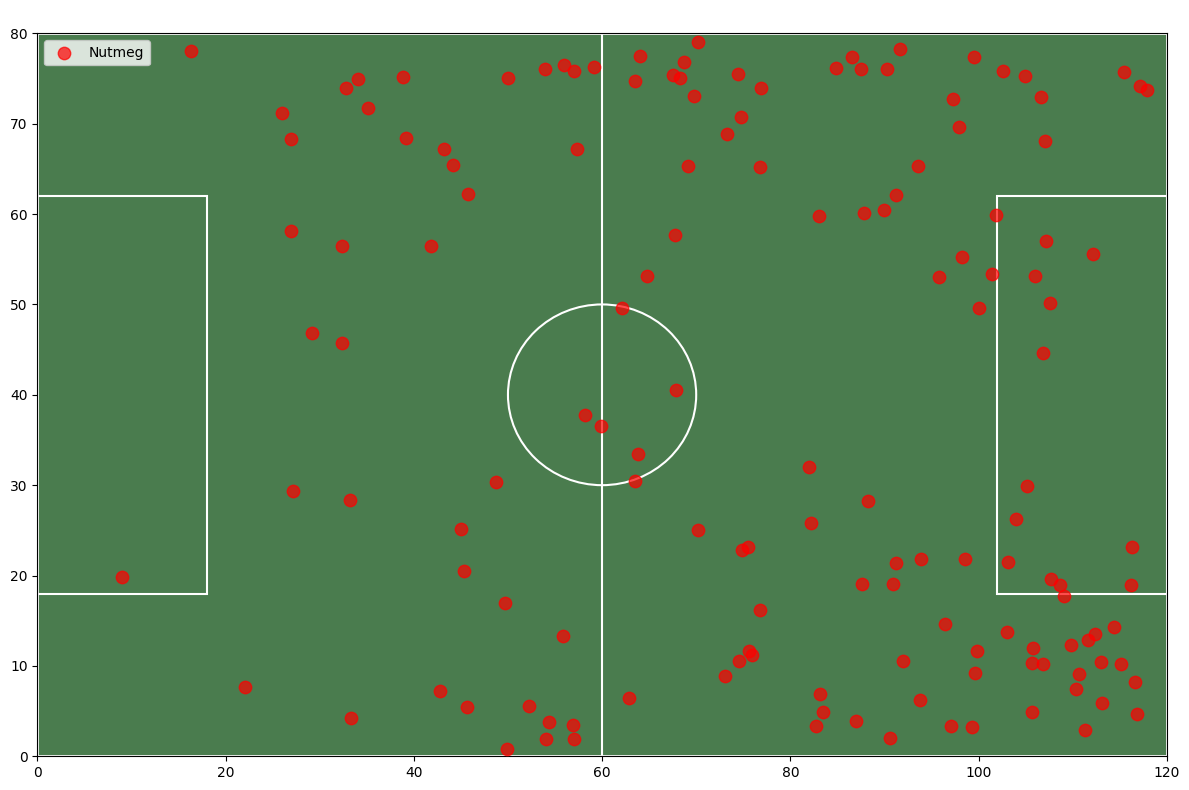

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(12, 8))

# Gambar lapangan
ax.set_xlim(0, 120)
ax.set_ylim(0, 80)
ax.set_facecolor('#4a7c4e')

# Garis lapangan
ax.plot([0,120,120,0,0], [0,0,80,80,0], 'white', linewidth=2)
ax.plot([60,60], [0,80], 'white', linewidth=1.5)
ax.add_patch(patches.Circle((60,40), 10, fill=False, color='white', linewidth=1.5))

# Kotak penalti
ax.add_patch(patches.Rectangle((0,18), 18, 44, fill=False, color='white', linewidth=1.5))
ax.add_patch(patches.Rectangle((102,18), 18, 44, fill=False, color='white', linewidth=1.5))

# Plot nutmeg
nutmeg_coords = dribbles[dribbles['dribble_nutmeg']==True]
ax.scatter(nutmeg_coords['x'], nutmeg_coords['y'], 
           c='red', s=80, alpha=0.7, zorder=5, label='Nutmeg')

ax.set_title('Nutmeg locations — FIFA World Cup 2022', color='white', fontsize=14)
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('data/nutmeg_locations.png', dpi=150, bbox_inches='tight')
plt.show()

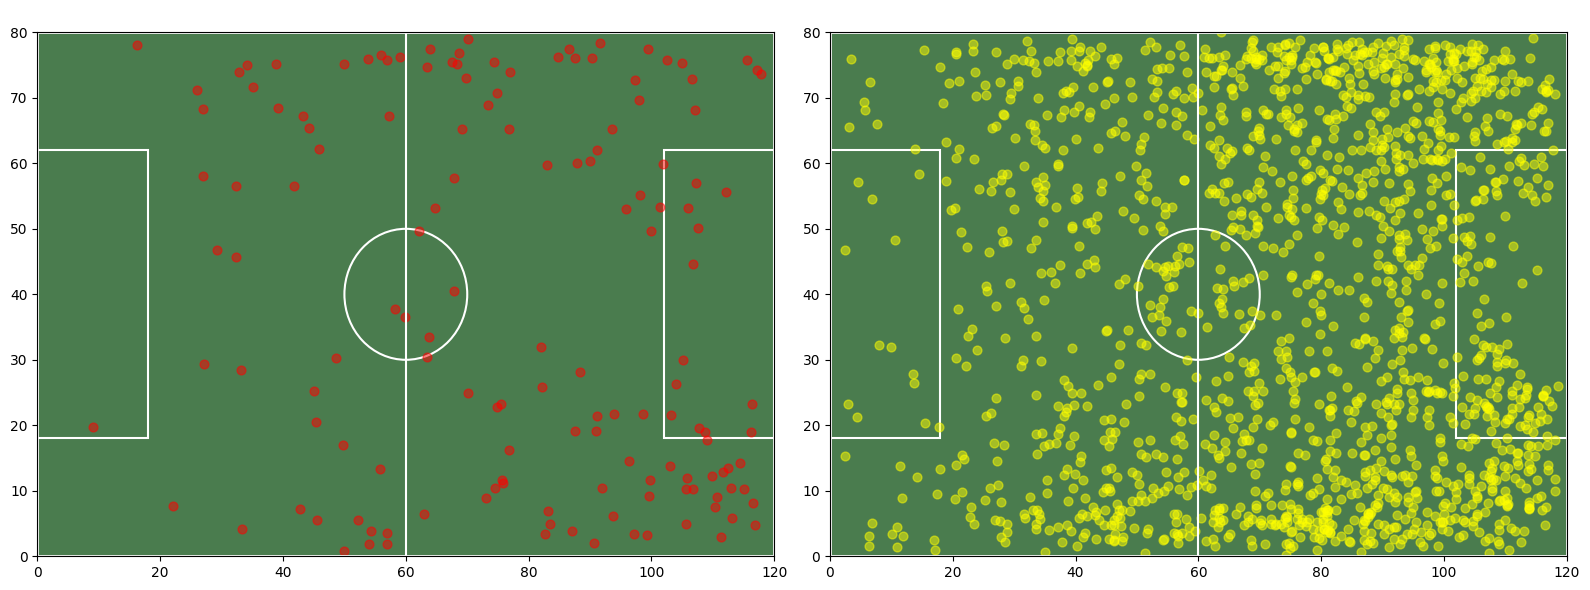

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (label, data, color) in zip(axes, [
    ('Nutmeg (145)', dribbles[dribbles['dribble_nutmeg']==True], 'red'),
    ('Dribble biasa (1648)', dribbles[dribbles['dribble_nutmeg']==False], 'yellow')
]):
    ax.set_xlim(0, 120)
    ax.set_ylim(0, 80)
    ax.set_facecolor('#4a7c4e')
    ax.plot([0,120,120,0,0], [0,0,80,80,0], 'white', linewidth=2)
    ax.plot([60,60], [0,80], 'white', linewidth=1.5)
    ax.add_patch(patches.Circle((60,40), 10, fill=False, color='white', linewidth=1.5))
    ax.add_patch(patches.Rectangle((0,18), 18, 44, fill=False, color='white', linewidth=1.5))
    ax.add_patch(patches.Rectangle((102,18), 18, 44, fill=False, color='white', linewidth=1.5))
    ax.scatter(data['x'], data['y'], c=color, s=40, alpha=0.5)
    ax.set_title(label, color='white', fontsize=13)

plt.tight_layout()
plt.savefig('data/nutmeg_vs_dribble.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
print(dribbles.groupby('dribble_nutmeg')['under_pressure'].value_counts(normalize=True))

dribble_nutmeg  under_pressure
False           True              1.0
True            True              1.0
Name: proportion, dtype: float64


In [13]:
print(df[df['type'] == 'Dribble']['under_pressure'].value_counts(dropna=False))

under_pressure
True    1793
Name: count, dtype: int64


In [14]:
print(dribbles.groupby('dribble_nutmeg')['dribble_outcome'].value_counts(normalize=True))

dribble_nutmeg  dribble_outcome
False           Complete           0.530947
                Incomplete         0.469053
True            Incomplete         0.572414
                Complete           0.427586
Name: proportion, dtype: float64


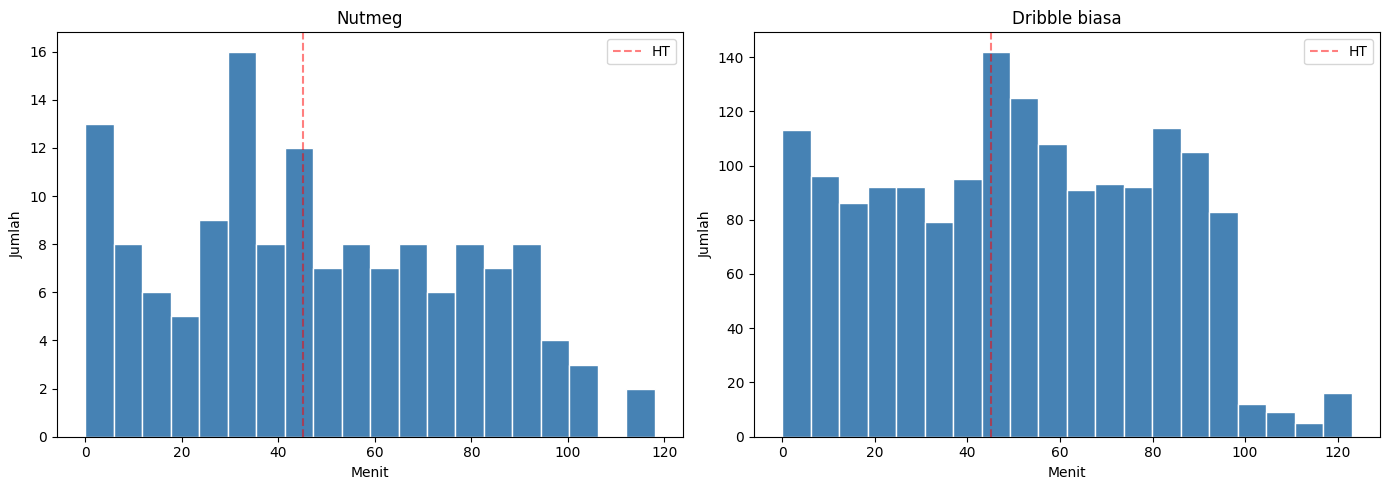

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, data) in zip(axes, [
    ('Nutmeg', dribbles[dribbles['dribble_nutmeg']==True]),
    ('Dribble biasa', dribbles[dribbles['dribble_nutmeg']==False])
]):
    ax.hist(data['minute'], bins=20, color='steelblue', edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel('Menit')
    ax.set_ylabel('Jumlah')
    ax.axvline(45, color='red', linestyle='--', alpha=0.5, label='HT')
    ax.legend()

plt.tight_layout()
plt.savefig('data/nutmeg_by_minute.png', dpi=150)
plt.show()

In [16]:
print("=== WC 2022 SB-EDA SUMMARY ===")
print(f"Total dribble: {len(dribbles)}")
print(f"Total nutmeg: {dribbles['dribble_nutmeg'].sum()}")
print(f"Nutmeg rate: {dribbles['dribble_nutmeg'].mean()*100:.1f}%")
print(f"\nTop 3 pemain nutmeg:")
print(nutmegs['player'].value_counts().head(3))
print(f"\nTop 3 tim nutmeg:")
print(nutmegs['team'].value_counts().head(3))
print(f"\nNutmeg outcome - Complete: {(nutmegs['dribble_outcome']=='Complete').mean()*100:.1f}%")
print(f"Dribble biasa outcome - Complete: {(dribbles[dribbles['dribble_nutmeg']==False]['dribble_outcome']=='Complete').mean()*100:.1f}%")

=== WC 2022 SB-EDA SUMMARY ===
Total dribble: 1793
Total nutmeg: 145
Nutmeg rate: 8.1%

Top 3 pemain nutmeg:
player
Kylian Mbappé Lottin         5
Antony Matheus dos Santos    4
Daniel Olmo Carvajal         3
Name: count, dtype: int64

Top 3 tim nutmeg:
team
Brazil       16
Portugal     11
Argentina    10
Name: count, dtype: int64

Nutmeg outcome - Complete: 42.8%
Dribble biasa outcome - Complete: 53.1%


In [17]:
dribbles.to_csv('data/processed/wc2022sb_dribbles.csv', index=False)
print("Tersimpan!")

Tersimpan!


In [18]:
relevant_cols = [
    'id', 'match_id', 'player', 'player_id', 'team', 'team_id',
    'minute', 'second', 'period', 'x', 'y',
    'dribble_nutmeg', 'dribble_outcome', 'dribble_overrun', 'dribble_no_touch',
    'play_pattern', 'position'
]

dribbles_clean = dribbles[relevant_cols].copy()
print(dribbles_clean.shape)
print(dribbles_clean.isnull().sum())

(1793, 17)
id                     0
match_id               0
player                 0
player_id              0
team                   0
team_id                0
minute                 0
second                 0
period                 0
x                      0
y                      0
dribble_nutmeg         0
dribble_outcome        0
dribble_overrun     1664
dribble_no_touch    1781
play_pattern           0
position               0
dtype: int64


In [19]:
print(dribbles_clean['dribble_overrun'].value_counts(dropna=False))
print(dribbles_clean['dribble_no_touch'].value_counts(dropna=False))

dribble_overrun
NaN     1664
True     129
Name: count, dtype: int64
dribble_no_touch
NaN     1781
True      12
Name: count, dtype: int64


In [20]:
dribbles_clean['dribble_overrun'] = dribbles_clean['dribble_overrun'].fillna(False)
dribbles_clean['dribble_no_touch'] = dribbles_clean['dribble_no_touch'].fillna(False)

print(dribbles_clean.isnull().sum().sum())

0


In [21]:
dribbles_clean.to_csv('data/processed/wc2022sb_dribbles_clean.csv', index=False)
print(dribbles_clean.shape)
print(dribbles_clean.dtypes)

(1793, 17)
id                      str
match_id              int64
player                  str
player_id           float64
team                    str
team_id               int64
minute                int64
second                int64
period                int64
x                   float64
y                   float64
dribble_nutmeg       object
dribble_outcome         str
dribble_overrun      object
dribble_no_touch     object
play_pattern            str
position                str
dtype: object
